In [8]:
stan_code = r"""
data {
  int N_obs;
  int N_cens;
  vector[N_obs] Y_obs;
  real L;
}

parameters {
  real mu;
  real<lower=0> sigma;
}

model {
  Y_obs[1:N_obs] ~ normal(mu, sigma);
  target += N_cens * normal_lcdf(L | mu, sigma);
}
"""

Threshold L=25.000, N_obs=4, N_cens=2


12:28:32 - cmdstanpy - INFO - compiling stan file C:\git\Matsuura2022_Bayesian_Statistical_Modeling_with_Stan_R_and_Python\yndk\ch07\censoring_model.stan to exe file C:\git\Matsuura2022_Bayesian_Statistical_Modeling_with_Stan_R_and_Python\yndk\ch07\censoring_model.exe
12:28:53 - cmdstanpy - INFO - compiled model executable: C:\git\Matsuura2022_Bayesian_Statistical_Modeling_with_Stan_R_and_Python\yndk\ch07\censoring_model.exe
12:28:53 - cmdstanpy - INFO - compiled model executable: C:\git\Matsuura2022_Bayesian_Statistical_Modeling_with_Stan_R_and_Python\yndk\ch07\censoring_model.exe
12:28:53 - cmdstanpy - INFO - CmdStan start processing
12:28:53 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

12:28:53 - cmdstanpy - INFO - CmdStan done processing.
12:28:53 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 3 had 7 divergent transitions (0.7%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.
12:28:53 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 3 had 7 divergent transitions (0.7%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.



          Mean      MCSE    StdDev      MAD        5%       50%      95%  \
lp__  -10.3744  0.093987   1.57868  1.10203 -13.53050  -9.88526  -8.8810   
mu     24.3754  1.024060  15.12400  4.78820   9.18021  27.05320  35.2763   
sigma  16.3150  1.284880  22.12890  5.71527   4.45869  10.24980  46.3055   

       ESS_bulk  ESS_tail    R_hat  
lp__    420.218   291.734  1.01298  
mu      615.106   276.154  1.00925  
sigma   439.452   347.733  1.01093  
          Mean      MCSE    StdDev      MAD        5%       50%      95%  \
lp__  -10.3744  0.093987   1.57868  1.10203 -13.53050  -9.88526  -8.8810   
mu     24.3754  1.024060  15.12400  4.78820   9.18021  27.05320  35.2763   
sigma  16.3150  1.284880  22.12890  5.71527   4.45869  10.24980  46.3055   

       ESS_bulk  ESS_tail    R_hat  
lp__    420.218   291.734  1.01298  
mu      615.106   276.154  1.00925  
sigma   439.452   347.733  1.01093  


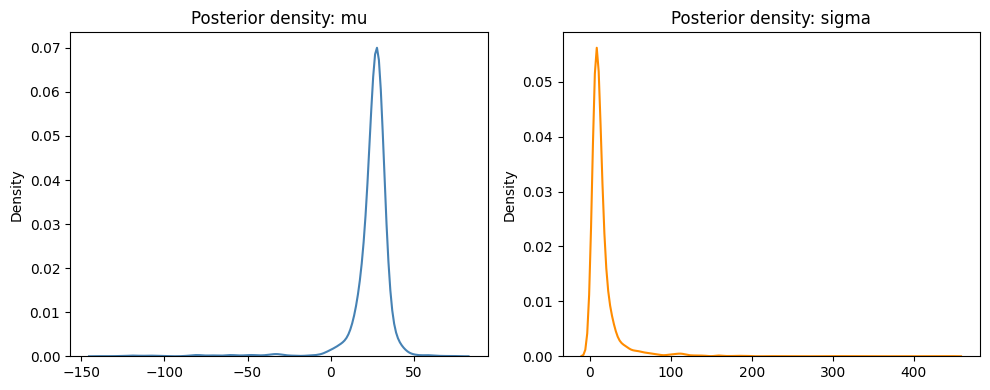

Posterior means -> mu: 24.3753734079 , sigma: 16.3150126575


In [9]:
# 2) Load data from CSV, prepare inputs, compile and sample via cmdstanpy
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cmdstanpy

# Adjust path if needed
csv_path = os.path.join('./', 'data-protein.csv')

df = pd.read_csv(csv_path)
# Expect a column named 'Y' (observations); adjust if different
if 'Y' not in df.columns:
    raise ValueError("CSV must contain a column named 'Y' with observed values (and possibly censored threshold L).")

# Example censoring scheme:
# Values below threshold L are left-censored at L. If CSV has column 'L', use it; else choose L as min detectable.
# L = float(df['Y'].quantile(0.1)) if 'L' not in df.columns else float(df['L'].iloc[0])

# Split observed and censored
Y_all = df['Y'].to_numpy()
#Y_obs = Y_all[Y_all >= L]
idx = np.where(df.Y.str.match('<'))[0]
Y_obs = df.Y[~df.index.isin(idx)].astype(float)
L = df.Y[df.index.isin(idx)].str.extract(r'([\d\.]+)').astype(float)[0][0]

N_obs = int(Y_obs.shape[0])
N_cens = len(idx)

print(f"Threshold L={L:.3f}, N_obs={N_obs}, N_cens={N_cens}")

# Write Stan code to file and compile
stan_file = os.path.join('./', 'censoring_model.stan')
with open(stan_file, 'w', encoding='utf-8') as f:
    f.write(stan_code)

model = cmdstanpy.CmdStanModel(stan_file=stan_file)

stan_data = {
    'N_obs': N_obs,
    'N_cens': N_cens,
    'Y_obs': Y_obs.astype(float),
    'L': float(L),
}

fit = model.sample(data=stan_data, seed=2025, chains=4, parallel_chains=4)
print(fit.summary())

# Extract posterior draws
mu_draws = fit.stan_variable('mu')
sigma_draws = fit.stan_variable('sigma')

# Plot posterior densities
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.kdeplot(mu_draws, ax=axs[0], color='steelblue')
axs[0].set_title('Posterior density: mu')
sns.kdeplot(sigma_draws, ax=axs[1], color='darkorange')
axs[1].set_title('Posterior density: sigma')
plt.tight_layout()
plt.show()

print('Posterior means -> mu:', float(np.mean(mu_draws)), ', sigma:', float(np.mean(sigma_draws)))

## Mathematical concept: Gaussian model with left-censoring via log CDF contribution

We model uncensored observations $Y_{\text{obs}}$ as i.i.d. normal and handle left-censored data by adding the log CDF of the censoring threshold.

- Parameters: mean $\mu \in \mathbb{R}$, standard deviation $\sigma>0$.
- Likelihood for observed values:
$$
Y_{\text{obs}, i} \sim \mathcal{N}(\mu, \sigma^2), \quad i=1,\dots,N_{\text{obs}}.
$$
- Contribution of left-censored values at threshold $L$:
If there are $N_{\text{cens}}$ values censored because they fell below $L$, the joint likelihood multiplies by $\Pr(Y<L)$ for each censored datum. In log terms,
$$
\log p(\text{censored}\mid \mu,\sigma) = N_{\text{cens}}\,\log\Big(\Phi\Big(\frac{L-\mu}{\sigma}\Big)\Big),
$$
where $\Phi$ is the standard normal CDF. In Stan, this is implemented as
$$
\texttt{target += N\_cens * normal\_lcdf(L | mu, sigma)}.
$$

- Overall log posterior (up to prior terms):
$$
\log p(\mu,\sigma \mid Y) = \sum_{i=1}^{N_{\text{obs}}} \log \mathcal{N}(Y_{\text{obs}, i}\mid \mu, \sigma) \;+
\; N_{\text{cens}}\,\log\Phi\Big(\frac{L-\mu}{\sigma}\Big) \; + \; \log p(\mu,\sigma).
$$

This approach correctly accounts for the probability mass of censored observations without fabricating values. The sampler then explores $(\mu,\sigma)$ consistent with both the observed data and the censoring mechanism.

In [20]:
# 5) Simulate censored data, run Stan, and plot posterior densities with true values
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cmdstanpy

# True parameters
mu_true = 2.0
sigma_true = 0.8
N_total = 300

# Simulate raw data
rng = np.random.default_rng(2025)
y_raw = rng.normal(mu_true, sigma_true, size=N_total)

# Choose a censoring threshold L (left-censoring)
L = mu_true - 0.5  # some values will fall below L

# Build observed and censored sets
Y_obs = y_raw[y_raw >= L]
N_obs = int(Y_obs.shape[0])
N_cens = int(np.sum(y_raw < L))

print(f"Simulated: mu_true={mu_true}, sigma_true={sigma_true}, L={L}, N_obs={N_obs}, N_cens={N_cens}")

Simulated: mu_true=2.0, sigma_true=0.8, L=1.5, N_obs=213, N_cens=87


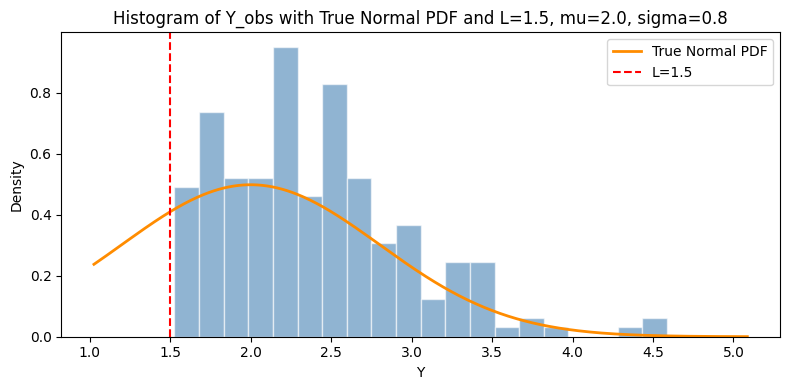

In [22]:
# Plot histogram of observed values, overlay true Normal(mu_true, sigma_true) PDF, and draw L
fig_hist, ax_hist = plt.subplots(figsize=(8, 4))

# Histogram for Y_obs
ax_hist.hist(Y_obs, bins=int(np.ptp(Y_obs) / float(bin_width)), density=True, alpha=0.6, color='steelblue', edgecolor='white')

# True normal PDF
x_plot = np.linspace(np.min(Y_obs) - 0.5, np.max(Y_obs) + 0.5, 400)
pdf_plot = (1.0 / (sigma_true * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_plot - mu_true) / sigma_true) ** 2)
ax_hist.plot(x_plot, pdf_plot, color='darkorange', linewidth=2, label='True Normal PDF')

# Censoring threshold L
ax_hist.axvline(L, color='red', linestyle='--', linewidth=1.5, label=f'L={L}')

ax_hist.set_title(f'Histogram of Y_obs with True Normal PDF and L={L}, mu={mu_true}, sigma={sigma_true}')
ax_hist.set_xlabel('Y')
ax_hist.set_ylabel('Density')
ax_hist.legend()
plt.tight_layout()
plt.show()

12:40:19 - cmdstanpy - INFO - compiling stan file C:\git\Matsuura2022_Bayesian_Statistical_Modeling_with_Stan_R_and_Python\yndk\ch07\censoring_model.stan to exe file C:\git\Matsuura2022_Bayesian_Statistical_Modeling_with_Stan_R_and_Python\yndk\ch07\censoring_model.exe
12:40:40 - cmdstanpy - INFO - compiled model executable: C:\git\Matsuura2022_Bayesian_Statistical_Modeling_with_Stan_R_and_Python\yndk\ch07\censoring_model.exe
12:40:40 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

12:40:40 - cmdstanpy - INFO - CmdStan done processing.
12:40:40 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'censoring_model.stan', line 15, column 2 to column 37)
Consider re-running with show_console=True if the above output is unclear!



             Mean      MCSE    StdDev       MAD          5%         50%  \
lp__  -151.538000  0.024961  1.035700  0.706459 -153.616000 -151.200000   
mu       1.982240  0.000961  0.051926  0.051090    1.894160    1.982790   
sigma    0.851214  0.000914  0.045156  0.044015    0.779817    0.849306   

              95%  ESS_bulk  ESS_tail    R_hat  
lp__  -150.578000   1803.05   2195.71  1.00097  
mu       2.067420   2946.22   2595.90  1.00070  
sigma    0.928041   2511.08   2255.44  1.00152  


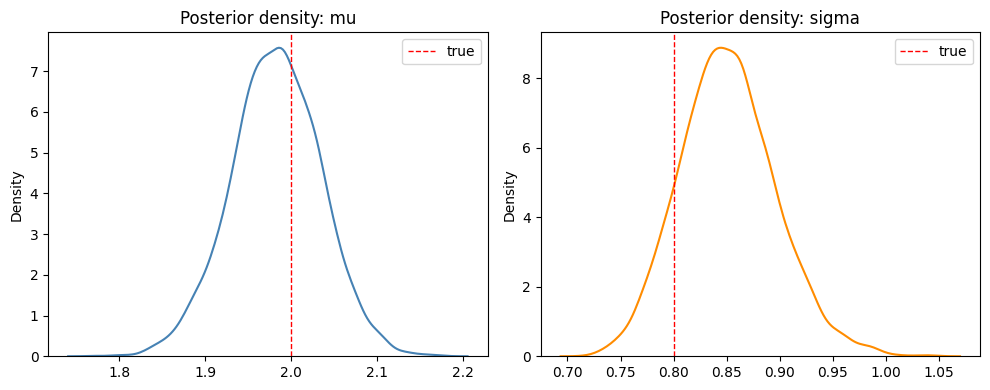

Posterior means -> mu: 1.9822411275 , sigma: 0.85121409025


In [19]:
# Ensure Stan code is written and compile
stan_file = os.path.join('./', 'censoring_model.stan')
with open(stan_file, 'w', encoding='utf-8') as f:
    f.write(stan_code)

model = cmdstanpy.CmdStanModel(stan_file=stan_file)

stan_data = {
    'N_obs': N_obs,
    'N_cens': N_cens,
    'Y_obs': Y_obs.astype(float),
    'L': float(L),
}

fit_sim = model.sample(data=stan_data, seed=2025, chains=4, parallel_chains=4)
print(fit_sim.summary())

# Extract posterior draws
mu_draws = fit_sim.stan_variable('mu')
sigma_draws = fit_sim.stan_variable('sigma')

# Plot posterior densities with true value lines
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.kdeplot(mu_draws, ax=axs[0], color='steelblue')
axs[0].axvline(mu_true, color='red', linestyle='--', linewidth=1, label='true')
axs[0].set_title('Posterior density: mu')
axs[0].legend()

sns.kdeplot(sigma_draws, ax=axs[1], color='darkorange')
axs[1].axvline(sigma_true, color='red', linestyle='--', linewidth=1, label='true')
axs[1].set_title('Posterior density: sigma')
axs[1].legend()

plt.tight_layout()
plt.show()

print('Posterior means -> mu:', float(np.mean(mu_draws)), ', sigma:', float(np.mean(sigma_draws)))